In [1]:
# Deactivate distracting warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
from utils.data_processing import *
from utils.visualization import load_data, plot_event_count, plot_kde, plot_goal_positions
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

In [141]:
path = "./idsse-data/DFL-MAT-J03WR9/"
file_name_pos = "DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WR9.xml"
file_name_infos = "DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WR9.xml"
file_name_events = "DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WR9.xml"
xy_objects, events, pitch, possession, ballstatus, teamsheets = load_data(path, file_name_pos, file_name_infos, file_name_events)

len(xy_objects["firstHalf"]["Home"][0])=40

In [100]:
def get_first_half_players(valid_counts, positions):
    """
    valid_counts: 각 컬럼별 정상 데이터 개수가 담긴 리스트나 배열 (예: 40개 요소)
    positions: 선수 인덱스를 인덱스로 갖는 포지션 Series (예: 20개 요소)
    """
    starting_players = {}
    
    # 총 선수 명수 계산 (컬럼 수 / 2)
    num_players = len(valid_counts) // 2
    
    for i in range(num_players):
        # 선수의 x좌표 컬럼 인덱스 계산 (0, 2, 4, 6...)
        # y좌표는 2*i + 1이지만, x좌표 하나만 검사해도 출전 여부 파악 가능
        x_col_idx = i * 2 
        
        # 해당 선수의 좌표 데이터가 1개라도 존재한다면(0보다 크다면) 출전한 선수로 간주
        if valid_counts[x_col_idx] > 0:
            # 포지션 Series에서 해당 인덱스(i)의 포지션 값을 가져옴
            pos = positions[i]
            
            # 딕셔너리에 추가
            starting_players[i] = pos
            
    return starting_players

In [142]:
Home_first = xy_objects["firstHalf"]["Home"].xy 
Away_first = xy_objects["firstHalf"]["Away"].xy 
Possession_first = possession["firstHalf"].code
non_nan_counts = np.sum(~np.isnan(Home_first), axis=0)
non_nan_counts_2 = np.sum(~np.isnan(Away_first), axis=0)
print("각 컬럼별 정상(non-NaN) 데이터 개수:")
print(non_nan_counts)
print(non_nan_counts_2)

각 컬럼별 정상(non-NaN) 데이터 개수:
[    0     0 68354 68354     0     0 68354 68354     0     0     0     0
 68354 68354 68354 68354 68354 68354 68354 68354 68354 68354     0     0
     0     0 68354 68354 68354 68354 68354 68354 68354 68354     0     0
     0     0     0     0]
[68354 68354 68354 68354     0     0     0     0     0     0 68354 68354
 68354 68354 68354 68354 68354 68354 68354 68354     0     0     0     0
 68354 68354 68354 68354 68354 68354     0     0 68354 68354     0     0
     0     0     0     0]


In [143]:
result_Home = get_first_half_players(non_nan_counts, teamsheets['Home']['position'])
result_Away = get_first_half_players(non_nan_counts_2, teamsheets['Away']['position'])

print("Home 전반전 출전 선수 (인덱스: 포지션):")
for idx, pos in result_Home.items():
    print(f"Index {idx:2d} : {pos}")
print("Away 전반전 출전 선수 (인덱스: 포지션):")
for idx, pos in result_Away.items():
    print(f"Index {idx:2d} : {pos}")

Home 전반전 출전 선수 (인덱스: 포지션):
Index  1 : STL
Index  3 : RV
Index  6 : DML
Index  7 : DMR
Index  8 : STR
Index  9 : OLM
Index 10 : TW
Index 13 : IVR
Index 14 : ORM
Index 15 : IVL
Index 16 : LV
Away 전반전 출전 선수 (인덱스: 포지션):
Index  0 : ZO
Index  1 : TW
Index  5 : STZ
Index  6 : RV
Index  7 : OLM
Index  8 : ORM
Index  9 : DMR
Index 12 : LV
Index 13 : IVR
Index 14 : DML
Index 16 : IVL


In [103]:
Home_first_df = pd.DataFrame(Home_first)
Away_first_df = pd.DataFrame(Away_first)
Possession_first_df = pd.DataFrame(Possession_first)

In [104]:
def filter_defenders(result, target_positions = ['LV', 'IVL', 'IVR', 'RV']):
    target_columns = []
    new_column_names = []

    for player_idx, pos in result.items():
        if pos in target_positions:
            # x좌표 컬럼: 인덱스 * 2, y좌표 컬럼: 인덱스 * 2 + 1
            x_col = player_idx * 2
            y_col = player_idx * 2 + 1
            
            target_columns.extend([x_col, y_col])
            new_column_names.extend([f'{pos}_x', f'{pos}_y'])
    return target_columns, new_column_names

In [105]:
target_col_home, new_col_home = filter_defenders(result_Home)
target_col_away, new_col_away = filter_defenders(result_Away)

filtered_df_Home = Home_first_df[target_col_home]
filtered_df_Home.columns = new_col_home

filtered_df_Away = Away_first_df[target_col_away]
filtered_df_Away.columns = new_col_away

print(filtered_df_Home.head())
print(filtered_df_Away.head())

    LV_x   LV_y   RV_x   RV_y  IVR_x  IVR_y  IVL_x  IVL_y
0  13.08 -13.71  17.26  20.85  20.16   7.08  18.84  -4.49
1  13.06 -13.75  17.23  20.88  20.12   7.09  18.79  -4.49
2  13.05 -13.78  17.18  20.91  20.09   7.10  18.75  -4.49
3  13.03 -13.82  17.15  20.94  20.06   7.12  18.70  -4.48
4  13.02 -13.87  17.11  20.98  20.02   7.13  18.65  -4.48
   IVR_x  IVR_y   RV_x   RV_y  IVL_x  IVL_y   LV_x   LV_y
0 -16.05   1.04 -12.80 -18.85 -20.77   9.07 -13.80  25.72
1 -15.98   0.99 -12.83 -18.86 -20.77   9.11 -13.78  25.74
2 -15.92   0.94 -12.88 -18.86 -20.77   9.14 -13.75  25.76
3 -15.86   0.89 -12.91 -18.87 -20.77   9.19 -13.73  25.78
4 -15.80   0.84 -12.94 -18.87 -20.78   9.22 -13.71  25.81


so candiate threshold is 4.5, 4.6, 4.7

In [106]:
def classify_morphology(row, x_columns):
    x_values = row[x_columns]
    x_min = x_values.max()
    x_max = x_values.min()
    x_range = abs(x_max - x_min)
    
    if x_range <= 5.8:
        return 'line'
    
    # 3등분
    delta = x_range / 3
    x_low_max = x_min - delta
    x_high_min = x_max + delta
    
    # 각 선수의 영역 분류
    zones = {}
    for col in x_columns:
        x = row[col]
        if x >= x_low_max:
            zones[col] = 'low'
        elif x <= x_high_min:
            zones[col] = 'high'
        else:
            zones[col] = 'middle'
    
    # 영역별 카운트
    zone_counts = {'high': 0, 'middle': 0, 'low': 0}
    for zone in zones.values():
        zone_counts[zone] += 1
    
    # === 패턴 분류 ===
    
    # 1. 3명 low, 1명 high
    if zone_counts['low'] == 3 and zone_counts['high'] == 1:
        if zones['RV_x'] == 'high':
            return '0002'
        if zones['IVR_x'] == 'high':
            return '0020'
        if zones['IVL_x'] == 'high':
            return '0200'
        if zones['LV_x'] == 'high':
            return '2000'
    
    # 2. 3명 high, 1명 low
    if zone_counts['high'] == 3 and zone_counts['low'] == 1:
        if zones['RV_x'] == 'low':
            return '2220'
        if zones['IVR_x'] == 'low':
            return '2202'
        if zones['IVL_x'] == 'low':
            return '2022'
        if zones['LV_x'] == 'low':
            return '0222'
    
    # 3. 2명 high, 2명 low (middle 없음)
    if zone_counts['high'] == 2 and zone_counts['low'] == 2 and zone_counts['middle'] == 0:
        # 양 풀백 vs 센터백
        if zones['RV_x'] == 'high' and zones['LV_x'] == 'high':
            return '2002'
        if zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high':
            return '0220'
        
        # 좌우 분리
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high':
            return '0022'
        if zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2200'
        
        # 대각선
        # RV(RB) + IVL(LCB) 둘 다 high
        if zones['RV_x'] == 'high' and zones['IVL_x'] == 'high':
            return '0202'
        
        # LV(LB) + IVR(RCB) 둘 다 high  ← 이미지의 경우!
        if zones['LV_x'] == 'high' and zones['IVR_x'] == 'high':
            return '2020'
    
    # 4. Middle - One Up & Two Down -12
    if zone_counts['middle'] == 1:
        if zones['IVL_x'] == 'low' and zones['IVR_x'] == 'low':
            if zones['LV_x'] == 'middle' and zones['RV_x'] == 'high':
                return '1002'
            elif zones['LV_x'] == 'high' and zones['RV_x'] == 'middle':
                return '2001'
        if zones['LV_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['IVR_x'] == 'high' and zones['RV_x'] == 'low':
            return '1020'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0201'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2100'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'low':
            return '0012'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0120'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0210'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'low':
            return '0021'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1200'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2010'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0102'
    #5.Two Up & One Down - 12    
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0221'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2021'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0122'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2102'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2201'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0212'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2120'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1022'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2012'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'high':
            return '2210'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1202'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1220'
    if zone_counts['middle'] == 2:
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0112'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1012'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'low':
            return '0211'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1201'
        if zones['RV_x'] == 'high' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'middle':
            return '1102'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'low':
            return '0121'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'high' and zones['LV_x'] == 'middle':
            return '1210'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'high':
            return '2011'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'low' and zones['LV_x'] == 'middle':
            return '1021'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'high' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'middle':
            return '1120'
        if zones['RV_x'] == 'middle' and zones['IVR_x'] == 'low' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2101'
        if zones['RV_x'] == 'low' and zones['IVR_x'] == 'middle' and zones['IVL_x'] == 'middle' and zones['LV_x'] == 'high':
            return '2110'
    
    # 6. 기타
    return 'mixed_formation'
 
        

# 적용
x_columns = ['LV_x', 'IVL_x', 'IVR_x', 'RV_x']
y_columns = ['LV_y', 'IVL_y', 'IVR_y', 'RV_y']
filtered_df_Home['morphology'] = filtered_df_Home.apply(
    lambda row: classify_morphology(row, x_columns), axis=1
)
# direction 통일
filtered_df_Away_dir = filtered_df_Away.copy()
filtered_df_Away_dir[x_columns] = -filtered_df_Away_dir[x_columns]
filtered_df_Away_dir[y_columns] = -filtered_df_Away_dir[y_columns]
filtered_df_Away_dir['morphology'] = filtered_df_Away_dir.apply(
    lambda row: classify_morphology(row, x_columns), axis=1
)

print(filtered_df_Home[['LV_x', 'IVL_x', 'IVR_x', 'RV_x','morphology']].head(10))
print(filtered_df_Away_dir[['LV_x', 'IVL_x', 'IVR_x', 'RV_x','morphology']].head(10))


    LV_x  IVL_x  IVR_x   RV_x morphology
0  13.08  18.84  20.16  17.26       2001
1  13.06  18.79  20.12  17.23       2001
2  13.05  18.75  20.09  17.18       2001
3  13.03  18.70  20.06  17.15       2001
4  13.02  18.65  20.02  17.11       2001
5  13.00  18.60  19.99  17.07       2001
6  12.98  18.55  19.96  17.03       2001
7  12.95  18.49  19.92  16.99       2001
8  12.93  18.43  19.89  16.95       2001
9  12.91  18.37  19.86  16.91       2001
    LV_x  IVL_x  IVR_x   RV_x morphology
0  13.80  20.77  16.05  12.80       2012
1  13.78  20.77  15.98  12.83       2012
2  13.75  20.77  15.92  12.88       2012
3  13.73  20.77  15.86  12.91       2012
4  13.71  20.78  15.80  12.94       2012
5  13.69  20.78  15.74  12.99       2012
6  13.66  20.79  15.68  13.02       2012
7  13.64  20.79  15.63  13.06       2022
8  13.62  20.80  15.58  13.11       2022
9  13.60  20.81  15.54  13.15       2022


morphology
line    17142
2002    13233
2001     8341
1002     7382
2000     4254
0002     3743
2012     2651
1012     1707
2102     1275
0222     1114
0012     1092
2011      973
2022      632
2101      631
2200      620
2100      610
0200      506
2010      457
0020      394
1022      366
1200      356
1102      315
2020      314
1020      308
1021      302
0022      207
2202      186
1210      161
0210      150
2210      148
0021      147
1202      133
1201      126
0102      100
2021       97
2110       93
0201       84
0212       62
0122       58
1120       52
0202       51
0221       48
2220       42
2201       38
0211        5
2120        2
Name: count, dtype: int64


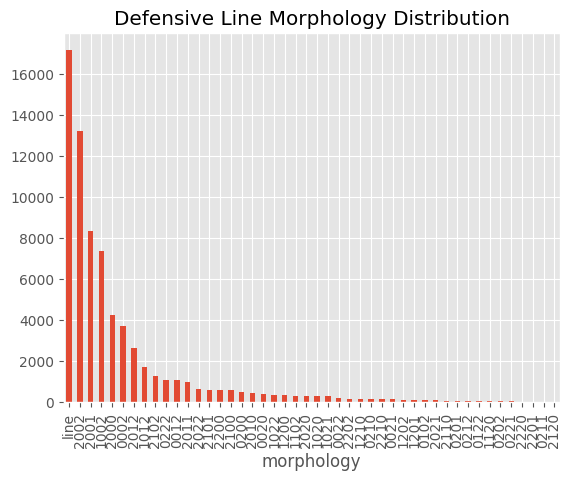

In [107]:
# 형태별 빈도 분석
# morphology_counts = filtered_df_Home['morphology'].value_counts()
# print(morphology_counts)
morphology_counts = filtered_df_Away_dir['morphology'].value_counts()
print(morphology_counts)
# 시간대별 형태 변화
import matplotlib.pyplot as plt
filtered_df_Away_dir['morphology'].value_counts().plot(kind='bar')
plt.title('Defensive Line Morphology Distribution')
plt.show()

In [108]:
import matplotlib.pyplot as plt
import os

def visualize_morphology_samples(df, x_columns, output_dir='morphology_images'):
    # 출력 디렉토리 생성
    os.makedirs(output_dir, exist_ok=True)
    
    # Y 좌표 컬럼 (X와 매칭되도록)
    y_columns = [col.replace('_x', '_y') for col in x_columns]
    
    # 각 morphology 유형별로 첫 번째 샘플 추출
    morphology_types = df['morphology'].unique()
    
    print(f"총 {len(morphology_types)}개의 morphology 유형 발견")
    print(f"유형: {morphology_types}\n")
    
    for morph_type in morphology_types:
        # 해당 유형의 첫 번째 샘플 가져오기
        sample = df[df['morphology'] == morph_type].iloc[0]
        
        # 좌표 추출
        x_coords = sample[x_columns].values
        y_coords = sample[y_columns].values
    
        
        fig, ax = plt.subplots(figsize=(12, 8))
        pitch.plot(ax=ax)
        
        # 수비 라인 그리기
        ax.plot(x_coords, y_coords, color='red', linestyle='--', 
                linewidth=2.5, zorder=1, label='Defensive Line')
        
        # 선수 위치 표시
        ax.scatter(x_coords, y_coords, color='blue', s=150, 
                   edgecolors='white', linewidth=2, zorder=2)
        
        # 포지션 라벨
        positions = ['LB', 'LCB', 'RCB', 'RB']
        for i in range(4):
            ax.text(x_coords[i], y_coords[i] + 2, positions[i], 
                    color='black', fontsize=12, ha='center', va='center', 
                    fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, 
                             edgecolor='black', boxstyle='round,pad=0.3'))
        
        # X 범위 계산 및 표시
        x_range = x_coords.max() - x_coords.min()
        
        # 제목 설정
        title = f"Morphology: {morph_type}\n"
        title += f"X Range: {x_range:.2f}m | Frame: {sample.name}"
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
        # 범례 추가
        ax.legend(loc='upper right', fontsize=10)
        
        # 저장
        filename = f"{output_dir}/{morph_type}.png"
        plt.savefig(filename, dpi=150, bbox_inches='tight', 
                    facecolor='white', edgecolor='none')
        print(f"✅ 저장 완료: {filename}")
        
        plt.close()
    
    print(f"\n🎉 총 {len(morphology_types)}개 이미지 생성 완료!")
    print(f"📁 저장 위치: {output_dir}/")


# 사용 예시
x_columns = ['LV_x', 'IVL_x', 'IVR_x', 'RV_x']
visualize_morphology_samples(filtered_df_Away_dir, x_columns, output_dir='morphology_images/J03WMX/away')
visualize_morphology_samples(filtered_df_Home, x_columns, output_dir='morphology_images/J03WMX/home')

총 46개의 morphology 유형 발견
유형: ['2012' '2022' '2021' '2011' '2001' '2101' '2202' '1202' '0202' 'line'
 '0212' '0222' '0122' '2000' '2102' '2002' '1002' '0002' '1102' '1012'
 '2010' '2100' '1022' '0022' '2110' '2210' '1210' '1200' '1201' '0012'
 '2020' '2200' '0102' '0020' '0210' '0200' '0201' '2201' '1020' '1021'
 '0221' '0021' '0211' '1120' '2120' '2220']

✅ 저장 완료: morphology_images/J03WMX/away/2012.png
✅ 저장 완료: morphology_images/J03WMX/away/2022.png
✅ 저장 완료: morphology_images/J03WMX/away/2021.png
✅ 저장 완료: morphology_images/J03WMX/away/2011.png
✅ 저장 완료: morphology_images/J03WMX/away/2001.png
✅ 저장 완료: morphology_images/J03WMX/away/2101.png
✅ 저장 완료: morphology_images/J03WMX/away/2202.png
✅ 저장 완료: morphology_images/J03WMX/away/1202.png
✅ 저장 완료: morphology_images/J03WMX/away/0202.png
✅ 저장 완료: morphology_images/J03WMX/away/line.png
✅ 저장 완료: morphology_images/J03WMX/away/0212.png
✅ 저장 완료: morphology_images/J03WMX/away/0222.png
✅ 저장 완료: morphology_images/J03WMX/away/0122.png
✅ 저장 완료: morphology

In [109]:
import pandas as pd

df = Home_first_df.copy()

# 2개 column씩 선수 한 명으로 묶기
player_pairs = [(df.columns[i], df.columns[i+1]) for i in range(0, df.shape[1], 2)]

# 각 선수별 유효 좌표 개수 계산
valid_counts = {}

for idx, (x_col, y_col) in enumerate(player_pairs):
    valid_count = df[[x_col, y_col]].notna().all(axis=1).sum()
    valid_counts[idx] = valid_count

# 유효 frame 수가 많은 상위 11명 선택
top11_player_indices = sorted(valid_counts, key=valid_counts.get, reverse=True)[:11]

# 선택된 11명의 column만 추출
selected_cols = []

for idx in top11_player_indices:
    x_col, y_col = player_pairs[idx]
    selected_cols.extend([x_col, y_col])

Home_first_11_df = df[selected_cols].copy()

print("선택된 선수 index:", top11_player_indices)
print("남은 column 수:", Home_first_11_df.shape[1])
print(Home_first_11_df.head())

선택된 선수 index: [0, 2, 3, 4, 5, 7, 9, 12, 14, 16, 18]
남은 column 수: 22
     0     1      4      5     6     7      8     9      10     11  ...    18  \
0  6.90  5.12  13.08 -13.71 -2.12 -7.09  47.37  0.25  17.26  20.85  ...  0.44   
1  6.82  5.10  13.06 -13.75 -2.28 -6.99  47.34  0.26  17.23  20.88  ...  0.37   
2  6.72  5.08  13.05 -13.78 -2.44 -6.88  47.30  0.26  17.18  20.91  ...  0.29   
3  6.62  5.05  13.03 -13.82 -2.61 -6.78  47.26  0.26  17.15  20.94  ...  0.21   
4  6.50  5.02  13.02 -13.87 -2.78 -6.66  47.22  0.27  17.11  20.98  ...  0.12   

      19     24    25    28     29     32    33     36    37  
0 -15.57  10.39 -3.39  1.40  13.05  18.84 -4.49  11.37  5.18  
1 -15.57  10.28 -3.39  1.39  13.05  18.79 -4.49  11.34  5.23  
2 -15.57  10.16 -3.39  1.39  13.05  18.75 -4.49  11.31  5.28  
3 -15.57  10.03 -3.39  1.38  13.06  18.70 -4.48  11.29  5.33  
4 -15.57   9.91 -3.39  1.37  13.06  18.65 -4.48  11.26  5.38  

[5 rows x 22 columns]


In [110]:
df = Away_first_df.copy()

player_pairs = [(df.columns[i], df.columns[i+1]) for i in range(0, df.shape[1], 2)]

valid_counts = {}

for idx, (x_col, y_col) in enumerate(player_pairs):
    valid_count = df[[x_col, y_col]].notna().all(axis=1).sum()
    valid_counts[idx] = valid_count

top11_away_indices = sorted(valid_counts, key=valid_counts.get, reverse=True)[:11]

selected_cols = []

for idx in top11_away_indices:
    x_col, y_col = player_pairs[idx]
    selected_cols.extend([x_col, y_col])

Away_first_11_df = df[selected_cols].copy()

print("선택된 Away 선수 index:", top11_away_indices)
print("남은 column 수:", Away_first_11_df.shape[1])
print(Away_first_11_df.head())

선택된 Away 선수 index: [0, 3, 7, 8, 9, 10, 12, 13, 14, 15, 16]
남은 column 수: 22
      0     1     6      7     14    15    16    17    18     19  ...     24  \
0 -46.73  0.18 -1.53  12.68  0.78 -0.54 -9.09 -1.96  0.42  33.22  ... -16.05   
1 -46.71  0.18 -1.45  12.68  0.85 -0.56 -9.06 -1.95  0.59  33.18  ... -15.98   
2 -46.68  0.18 -1.27  12.65  0.94 -0.59 -9.02 -1.94  0.77  33.14  ... -15.92   
3 -46.65  0.18 -1.07  12.64  1.03 -0.62 -8.99 -1.93  0.93  33.10  ... -15.86   
4 -46.62  0.18 -0.88  12.61  1.12 -0.65 -8.96 -1.91  1.10  33.06  ... -15.80   

     25     26     27     28    29     30     31    32     33  
0  1.04 -12.80 -18.85 -20.77  9.07 -13.80  25.72  0.52  10.26  
1  0.99 -12.83 -18.86 -20.77  9.11 -13.78  25.74  0.63  10.23  
2  0.94 -12.88 -18.86 -20.77  9.14 -13.75  25.76  0.74  10.22  
3  0.89 -12.91 -18.87 -20.77  9.19 -13.73  25.78  0.84  10.19  
4  0.84 -12.94 -18.87 -20.78  9.22 -13.71  25.81  0.95  10.16  

[5 rows x 22 columns]


In [111]:
def_cols = []

for i in range(1, 12):
    def_cols.extend([f"D{i}_x", f"D{i}_y"])

attk_cols = []

for i in range(1, 12):
    attk_cols.extend([f"A{i}_x", f"A{i}_y"])

Home_first_11_df.columns = def_cols
Away_first_11_df.columns = attk_cols

In [112]:
Away_11_df_inverse = -Away_first_11_df
Home_11_df_inverse = -Home_first_11_df

Away_11_df_inverse.columns = def_cols
Home_11_df_inverse.columns = attk_cols

In [113]:
Players_first_df = pd.concat(
    [Home_first_11_df, Away_first_11_df],
    axis=1
)
Players_second_df = pd.concat(
    [Away_11_df_inverse, Home_11_df_inverse],
    axis=1
)

print(Players_first_df.shape)
print(Players_first_df.head())
print(Players_second_df.shape)


(70708, 44)
   D1_x  D1_y   D2_x   D2_y  D3_x  D3_y   D4_x  D4_y   D5_x   D5_y  ...  \
0  6.90  5.12  13.08 -13.71 -2.12 -7.09  47.37  0.25  17.26  20.85  ...   
1  6.82  5.10  13.06 -13.75 -2.28 -6.99  47.34  0.26  17.23  20.88  ...   
2  6.72  5.08  13.05 -13.78 -2.44 -6.88  47.30  0.26  17.18  20.91  ...   
3  6.62  5.05  13.03 -13.82 -2.61 -6.78  47.26  0.26  17.15  20.94  ...   
4  6.50  5.02  13.02 -13.87 -2.78 -6.66  47.22  0.27  17.11  20.98  ...   

    A7_x  A7_y   A8_x   A8_y   A9_x  A9_y  A10_x  A10_y  A11_x  A11_y  
0 -16.05  1.04 -12.80 -18.85 -20.77  9.07 -13.80  25.72   0.52  10.26  
1 -15.98  0.99 -12.83 -18.86 -20.77  9.11 -13.78  25.74   0.63  10.23  
2 -15.92  0.94 -12.88 -18.86 -20.77  9.14 -13.75  25.76   0.74  10.22  
3 -15.86  0.89 -12.91 -18.87 -20.77  9.19 -13.73  25.78   0.84  10.19  
4 -15.80  0.84 -12.94 -18.87 -20.78  9.22 -13.71  25.81   0.95  10.16  

[5 rows x 44 columns]
(70708, 44)


In [114]:
Ball_first = xy_objects["firstHalf"]["Ball"].xy 
Ball_first_df = pd.DataFrame(Ball_first)
Ball_first_df.columns = ["ball_x", "ball_y"]

Ball_first_inverse = -Ball_first_df

In [115]:
Tracking_first_df = pd.concat(
    [Players_first_df, Ball_first_df],
    axis=1
)
Tracking_second_df = pd.concat(
    [Players_second_df, Ball_first_inverse],
    axis=1
)
print(Tracking_first_df.shape)
print(Tracking_second_df.shape)

(70708, 46)
(70708, 46)


In [116]:
Y1 = filtered_df_Home['morphology']
Y2 = filtered_df_Away_dir['morphology']
Tracking_second_df.head()


,D1_x,D1_y,D2_x,D2_y,D3_x,D3_y,D4_x,D4_y,D5_x,D5_y,...,A8_x,A8_y,A9_x,A9_y,A10_x,A10_y,A11_x,A11_y,ball_x,ball_y
0,46.73,-0.18,1.53,-12.68,-0.78,0.54,9.09,1.96,-0.42,-33.22,...,-10.39,3.39,-1.40,-13.05,-18.84,4.49,-11.37,-5.18,-0.18,0.17
1,46.71,-0.18,1.45,-12.68,-0.85,0.56,9.06,1.95,-0.59,-33.18,...,-10.28,3.39,-1.39,-13.05,-18.79,4.49,-11.34,-5.23,0.40,0.19
2,46.68,-0.18,1.27,-12.65,-0.94,0.59,9.02,1.94,-0.77,-33.14,...,-10.16,3.39,-1.39,-13.05,-18.75,4.49,-11.31,-5.28,0.97,0.21
3,46.65,-0.18,1.07,-12.64,-1.03,0.62,8.99,1.93,-0.93,-33.10,...,-10.03,3.39,-1.38,-13.06,-18.70,4.48,-11.29,-5.33,1.54,0.24
4,46.62,-0.18,0.88,-12.61,-1.12,0.65,8.96,1.91,-1.10,-33.06,...,-9.91,3.39,-1.37,-13.06,-18.65,4.48,-11.26,-5.38,2.12,0.26


In [117]:
print(Tracking_first_df.shape)
print(Y1.shape)
print(Y2.shape)
#print(Possession_first_df.shape) # 1 home, 2 away
print(Tracking_first_df.index.equals(Y1.index))

(70708, 46)
(70708,)
(70708,)
True


In [118]:
dataset_first_df = Tracking_first_df.copy()
dataset_first_df['possession'] = Possession_first_df.values
dataset_first_df["morphology"] = Y1.values
dataset_first_df.head()

dataset_second_df = Tracking_second_df.copy()
dataset_second_df['possession'] = Possession_first_df.values
dataset_second_df['morphology'] = Y2.values
dataset_second_df.head()

,D1_x,D1_y,D2_x,D2_y,D3_x,D3_y,D4_x,D4_y,D5_x,D5_y,...,A9_x,A9_y,A10_x,A10_y,A11_x,A11_y,ball_x,ball_y,possession,morphology
0,46.73,-0.18,1.53,-12.68,-0.78,0.54,9.09,1.96,-0.42,-33.22,...,-1.40,-13.05,-18.84,4.49,-11.37,-5.18,-0.18,0.17,2.0,2012
1,46.71,-0.18,1.45,-12.68,-0.85,0.56,9.06,1.95,-0.59,-33.18,...,-1.39,-13.05,-18.79,4.49,-11.34,-5.23,0.40,0.19,2.0,2012
2,46.68,-0.18,1.27,-12.65,-0.94,0.59,9.02,1.94,-0.77,-33.14,...,-1.39,-13.05,-18.75,4.49,-11.31,-5.28,0.97,0.21,2.0,2012
3,46.65,-0.18,1.07,-12.64,-1.03,0.62,8.99,1.93,-0.93,-33.10,...,-1.38,-13.06,-18.70,4.48,-11.29,-5.33,1.54,0.24,2.0,2012
4,46.62,-0.18,0.88,-12.61,-1.12,0.65,8.96,1.91,-1.10,-33.06,...,-1.37,-13.06,-18.65,4.48,-11.26,-5.38,2.12,0.26,2.0,2012


In [119]:
print(dataset_second_df.shape)
print(dataset_second_df.isna().sum().sum())
print(dataset_second_df["morphology"].value_counts())

(70708, 48)
0
morphology
line    17142
2002    13233
2001     8341
1002     7382
2000     4254
0002     3743
2012     2651
1012     1707
2102     1275
0222     1114
0012     1092
2011      973
2022      632
2101      631
2200      620
2100      610
0200      506
2010      457
0020      394
1022      366
1200      356
1102      315
2020      314
1020      308
1021      302
0022      207
2202      186
1210      161
0210      150
2210      148
0021      147
1202      133
1201      126
0102      100
2021       97
2110       93
0201       84
0212       62
0122       58
1120       52
0202       51
0221       48
2220       42
2201       38
0211        5
2120        2
Name: count, dtype: int64


In [120]:
dataset_first_df = dataset_first_df.reset_index(drop=True)
dataset_first_df["frame"] = dataset_first_df.index

dataset_second_df = dataset_second_df.reset_index(drop=True)
dataset_second_df["frame"] = dataset_second_df.index

In [121]:
defensive_df = dataset_first_df[dataset_first_df["possession"] == 2].copy()
defensive_df["frame_diff"] = defensive_df["frame"].diff()

defensive_df["segment_id"] = (defensive_df["frame_diff"] != 1).cumsum()

print(defensive_df["segment_id"].nunique())
print(defensive_df.groupby("segment_id").size().describe())

123
count     123.000000
mean      301.772358
std       439.411619
min         3.000000
25%        37.000000
50%       112.000000
75%       330.500000
max      2763.000000
dtype: float64


In [122]:
defensive_df_2 = dataset_second_df[dataset_second_df["possession"] == 1].copy()
defensive_df_2["frame_diff"] = defensive_df_2["frame"].diff()

defensive_df_2["segment_id"] = (defensive_df_2["frame_diff"] != 1).cumsum()

print(defensive_df_2["segment_id"].nunique())
print(defensive_df_2.groupby("segment_id").size().describe())

123
count     123.000000
mean      273.089431
std       488.894538
min         1.000000
25%        30.500000
50%        94.000000
75%       325.000000
max      4033.000000
dtype: float64


In [123]:
home_defensive_df = defensive_df.copy()
away_defensive_df = defensive_df_2.copy()

home_defensive_df["defense_team"] = "Home"
away_defensive_df["defense_team"] = "Away"

home_defensive_df["global_segment_id"] = (
    "Home_" + home_defensive_df["segment_id"].astype(str)
)

away_defensive_df["global_segment_id"] = (
    "Away_" + away_defensive_df["segment_id"].astype(str)
)

In [124]:
combined_defensive_df = pd.concat(
    [home_defensive_df, away_defensive_df],
    axis=0,
    ignore_index=True
)

print(combined_defensive_df[["defense_team", "segment_id", "global_segment_id"]].tail(10))
print(combined_defensive_df["global_segment_id"].nunique())

      defense_team  segment_id global_segment_id
70698         Away         123          Away_123
70699         Away         123          Away_123
70700         Away         123          Away_123
70701         Away         123          Away_123
70702         Away         123          Away_123
70703         Away         123          Away_123
70704         Away         123          Away_123
70705         Away         123          Away_123
70706         Away         123          Away_123
70707         Away         123          Away_123
246


In [125]:
combined_defensive_df.head()

,D1_x,D1_y,D2_x,D2_y,D3_x,D3_y,D4_x,D4_y,D5_x,D5_y,...,A11_y,ball_x,ball_y,possession,morphology,frame,frame_diff,segment_id,defense_team,global_segment_id
0,6.90,5.12,13.08,-13.71,-2.12,-7.09,47.37,0.25,17.26,20.85,...,10.26,0.18,-0.17,2.0,2001,0,NaN,1,Home,Home_1
1,6.82,5.10,13.06,-13.75,-2.28,-6.99,47.34,0.26,17.23,20.88,...,10.23,-0.40,-0.19,2.0,2001,1,1.0,1,Home,Home_1
2,6.72,5.08,13.05,-13.78,-2.44,-6.88,47.30,0.26,17.18,20.91,...,10.22,-0.97,-0.21,2.0,2001,2,1.0,1,Home,Home_1
3,6.62,5.05,13.03,-13.82,-2.61,-6.78,47.26,0.26,17.15,20.94,...,10.19,-1.54,-0.24,2.0,2001,3,1.0,1,Home,Home_1
4,6.50,5.02,13.02,-13.87,-2.78,-6.66,47.22,0.27,17.11,20.98,...,10.16,-2.12,-0.26,2.0,2001,4,1.0,1,Home,Home_1


In [126]:
# DFL-MAT-J03WMX
home_d_role_map = {
    "RV": "D5",
    "IVR": "D6",
    "IVL": "D10",
    "LV": "D2",
}

away_d_role_map = {
    "LV": "D10",
    "IVR": "D7",
    "RV": "D8",
    "IVL": "D9",
}
home_a_role_map = {
    "STZ" : "A3",
    "ZO" : "A1",
    "ORM" : "A9",
    "OLM" : "A7"
}

away_a_role_map = {
    "STZ" : "A3",
    "ZO" : "A2",
    "ORM" : "A6",
    "OLM" : "A5"
}

In [127]:
def make_canonical_defense_df(df, d_role_map, a_role_map):
    new_df = pd.DataFrame(index=df.index)

    # 1. 수비팀 4-back role 기준 정렬
    for role, src in d_role_map.items():
        new_df[f"D_{role}_x"] = df[f"{src}_x"]
        new_df[f"D_{role}_y"] = df[f"{src}_y"]

    # 2. 수비팀 4-back 제외 나머지 7명
    all_defenders = [f"D{i}" for i in range(1, 12)]
    four_back_sources = set(d_role_map.values())
    other_defenders = [p for p in all_defenders if p not in four_back_sources]

    for idx, src in enumerate(other_defenders, start=1):
        new_df[f"D_other{idx}_x"] = df[f"{src}_x"]
        new_df[f"D_other{idx}_y"] = df[f"{src}_y"]

    # 3. 공격팀 11명 전체
    for i in range(1, 12):
        new_df[f"O{i}_x"] = df[f"A{i}_x"]
        new_df[f"O{i}_y"] = df[f"A{i}_y"]

    # 4. 공격수 4명 role 기준 정렬
    for role, src in a_role_map.items():
        new_df[f"O_{role}_x"] = df[f"{src}_x"]
        new_df[f"O_{role}_y"] = df[f"{src}_y"]

    # 5. 공, label, metadata
    new_df["ball_x"] = df["ball_x"]
    new_df["ball_y"] = df["ball_y"]
    new_df["morphology"] = df["morphology"]
    new_df["defense_team"] = df["defense_team"]
    new_df["frame"] = df["frame"]
    new_df["global_segment_id"] = df["global_segment_id"]

    return new_df

In [128]:
home_rows = combined_defensive_df[combined_defensive_df["defense_team"] == "Home"].copy()
away_rows = combined_defensive_df[combined_defensive_df["defense_team"] == "Away"].copy()

# Home 수비상황: 공격팀은 Away → away_a_role_map 사용
home_canon_df = make_canonical_defense_df(
    home_rows,
    d_role_map=home_d_role_map,
    a_role_map=away_a_role_map
)

# Away 수비상황: 공격팀은 Home → home_a_role_map 사용
away_canon_df = make_canonical_defense_df(
    away_rows,
    d_role_map=away_d_role_map,
    a_role_map=home_a_role_map
)

canonical_df = pd.concat(
    [home_canon_df, away_canon_df],
    axis=0,
    ignore_index=True
)

print(canonical_df.shape)
print(canonical_df.head())

(70708, 58)
   D_RV_x  D_RV_y  D_IVR_x  D_IVR_y  D_IVL_x  D_IVL_y  D_LV_x  D_LV_y  \
0   17.26   20.85    20.16     7.08    18.84    -4.49   13.08  -13.71   
1   17.23   20.88    20.12     7.09    18.79    -4.49   13.06  -13.75   
2   17.18   20.91    20.09     7.10    18.75    -4.49   13.05  -13.78   
3   17.15   20.94    20.06     7.12    18.70    -4.48   13.03  -13.82   
4   17.11   20.98    20.02     7.13    18.65    -4.48   13.02  -13.87   

   D_other1_x  D_other1_y  ...  O_ORM_x  O_ORM_y  O_OLM_x  O_OLM_y  ball_x  \
0        6.90        5.12  ...     0.11   -21.87     0.42    33.22    0.18   
1        6.82        5.10  ...     0.08   -21.87     0.59    33.18   -0.40   
2        6.72        5.08  ...     0.04   -21.86     0.77    33.14   -0.97   
3        6.62        5.05  ...     0.01   -21.85     0.93    33.10   -1.54   
4        6.50        5.02  ...    -0.01   -21.85     1.10    33.06   -2.12   

   ball_y  morphology  defense_team  frame  global_segment_id  
0   -0.17       

In [129]:
canonical_df.to_csv("combined_defensive2.csv", index=False)

In [130]:
canonical_df.columns

Index(['D_RV_x', 'D_RV_y', 'D_IVR_x', 'D_IVR_y', 'D_IVL_x', 'D_IVL_y',
       'D_LV_x', 'D_LV_y', 'D_other1_x', 'D_other1_y', 'D_other2_x',
       'D_other2_y', 'D_other3_x', 'D_other3_y', 'D_other4_x', 'D_other4_y',
       'D_other5_x', 'D_other5_y', 'D_other6_x', 'D_other6_y', 'D_other7_x',
       'D_other7_y', 'O1_x', 'O1_y', 'O2_x', 'O2_y', 'O3_x', 'O3_y', 'O4_x',
       'O4_y', 'O5_x', 'O5_y', 'O6_x', 'O6_y', 'O7_x', 'O7_y', 'O8_x', 'O8_y',
       'O9_x', 'O9_y', 'O10_x', 'O10_y', 'O11_x', 'O11_y', 'O_STZ_x',
       'O_STZ_y', 'O_ZO_x', 'O_ZO_y', 'O_ORM_x', 'O_ORM_y', 'O_OLM_x',
       'O_OLM_y', 'ball_x', 'ball_y', 'morphology', 'defense_team', 'frame',
       'global_segment_id'],
      dtype='object')